# **Transjakarta User Behavior Analysis in April 2023**

---

## **1. Introduction**

### **1.1 Dataset Source & Context**
**Dataset:** [Transjakarta - Public Transportation Transaction](https://www.kaggle.com/datasets/dikisahkan/transjakarta-transportation-transaction)  
**Author:** dikisahkan  
**License:** Publicly available for analysis purposes

> **Disclaimer:** This dataset is simulated and **does not represent real Transjakarta data**. For further documentation, visit the dataset source above.

### **1.2 Transjakarta Services Overview**
Based on the dataset, Transjakarta offers five services:
- **BRT (Bus Rapid Transit):** Main bus service operating on dedicated corridors (busway lanes) with high capacity and long routes. It serves as the backbone of the Transjakarta system.
- **Mikrotrans:** Feeder service using small minibuses that operate in residential areas and narrow roads inaccessible to large buses.
- **Angkutan Pengumpan (Feeder Service):** Supporting transport that connects residential areas or transit points to main Transjakarta corridors or hubs.
- **RoyalTrans:** Premium bus service with enhanced comfort such as more spacious seating, better facilities, and lower passenger density, typically with higher fares.
- **Wisata:** Bus services operating on routes that connect tourism and recreational areas.

These services are further grouped into three major categories:

**1. Core Service**

Core Service refers to the main transportation backbone of Transjakarta, designed to support daily mobility and provide wide accessibility across Jakarta.

**Includes:** BRT (Bus Rapid Transit), Mikrotrans, and Angkutan Pengumpan (Feeder Service).

**Focus:** Accessibility, network integration, and daily commuting needs.

**2. Premium Service**

Premium Service provides higher comfort and improved travel experience compared to standard services

**Includes:** RoyalTrans. 

**Focus:** Comfort, service quality, and targeted commuter segments.

**3. Tourism Service**

Tourism Service is designed for recreational and non-routine travel, mainly supporting access to tourist destinations.

**Includes:** Wisata. 

**Focus:** Leisure travel, tourism access, and non-daily commuting purposes.

### **1.3 Background & Problem Statement**
Transjakarta operates multiple service types to serve diverse mobility needs. However, user behavior across these three service categories in April 2023 has not been systematically examined. This raises the question: **Are there differences in user behavior across these categories?**

### **1.4 Objectives**
This analysis aims to understand user behavior across the three Transjakarta service categories by examining demographic profiles, trip timing patterns, and usage intensity.

The objective is to identify whether each service category serves distinct user needs and mobility behaviors.

### **1.5 Sub-questions**
1. Do user demographics differ across the three Transjakarta service categories?
2. Are there distinct trip timing patterns across the three service categories?
3. Does usage intensity differ across the three Transjakarta service categories?


---
## **2. Import Package & Styling**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style='whitegrid',
    palette='pastel',
    font='Arial',
    rc={
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'axes.titleweight': 'semibold'
    }
)

---

## **3. Read Data**

This step loads the dataset into a Pandas DataFrame for further analysis.

In [2]:
df = pd.read_csv("Transjakarta.csv")

---

## **4. Data Understanding**

This stage focuses on understanding the dataset by examining its structure, data types, and overall quality. Initial exploration is conducted to identify missing values, duplicates, and basic patterns in the data.

Below is a description of the columns found in the Transjakarta data:

| **No.** | **Column Name**       | **Column Description**                                                              |
| -       |-----------------------|------------------------------------------------------------------------------------|
| 1. | transID          | Unique transaction ID for every transaction.                                       |
| 2. | payCardID        | The main customer identifier. |
| 3. | payCardBank      | The bank that issued the customer’s payment card.                                                  |
| 4. | payCardName      | The name of the cardholder.                                      |
| 5. | payCardSex       | The cardholder’s gender.                                       |
| 6. | payCardBirthDate | The cardholder’s year of birth.                                                             |
| 7. | corridorID       | The corridor identifier.                               |
| 8. | corridorName     | The route name, often indicating the starting and ending points.|
| 9. | direction        | The trip direction, with 0 representing outbound and 1 representing return.                                      |
| 10. | tapInStops      | The ID of the stop where the passenger taps in (entry).                             |
| 11. | tapInStopsName  | The name of the tap-in (entry) stop.                               |
| 12. | tapInStopsLat   | Latitude coordinate of the tap-in stop.                                                          |
| 13. | tapInStopsLon   | Longitude coordinate of the tap-in stop.                                                         |
| 14. | stopStartSeq    | The sequence number of the tap-in stop within the route.             |
| 15. | tapInTime       | The date and time when the passenger taps in.                                                    |
| 16. | tapOutStops     | The ID of the stop where the passenger taps out.                                |
| 17. | tapOutStopsName | The name of the tap-out (exit) stop.                                 |
| 18. | tapOutStopsLat  | Latitude coordinate of the tap-out stop.                                                         |
| 19. | tapOutStopsLon  | Longitude coordinate of the tap-out stop.                                                        |
| 20. | stopEndSeq      | The sequence number of the tap-out stop within the route.             |
| 21. | tapOutTime      | The date and time when the passenger taps out.                                                   |
| 22. | payAmount       | The fare paid by the customer, which may be zero for free trips or a positive value for paid trips.                             |


### 4.1 **Understanding Data Structure**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           37900 non-null  object 
 1   payCardID         37900 non-null  int64  
 2   payCardBank       37900 non-null  object 
 3   payCardName       37900 non-null  object 
 4   payCardSex        37900 non-null  object 
 5   payCardBirthDate  37900 non-null  int64  
 6   corridorID        36643 non-null  object 
 7   corridorName      35970 non-null  object 
 8   direction         37900 non-null  float64
 9   tapInStops        36687 non-null  object 
 10  tapInStopsName    37900 non-null  object 
 11  tapInStopsLat     37900 non-null  float64
 12  tapInStopsLon     37900 non-null  float64
 13  stopStartSeq      37900 non-null  int64  
 14  tapInTime         37900 non-null  object 
 15  tapOutStops       35611 non-null  object 
 16  tapOutStopsName   36556 non-null  object

From the dataset, it is observed that there are a total of 37,900 records in the Transjakarta data.

Before proceeding with the analysis, several columns below need to be adjusted to the appropriate data types to ensure consistency and correct analytical processing.

| Column Name  | Current Data Type | Revised Data Type |
|--------------|------------------|-------------------|
| direction    | float64          | int64             |
| tapInTime    | object           | datetime          |
| stopEndSeq   | float64          | int64             |
| tapOutTime   | object           | datetime          |
| payAmount    | float64          | int64             |




In [4]:
df.head().T

,0,1,2,3,4
transID,EIIW227B8L34VB,LGXO740D2N47GZ,DJWR385V2U57TO,JTUZ800U7C86EH,VMLO535V7F95NJ
payCardID,180062659848800,4885331907664776,4996225095064169,639099174703,570928206772
payCardBank,emoney,dki,dki,flazz,flazz
payCardName,Bajragin Usada,Gandi Widodo,Emong Wastuti,Surya Wacana,Embuh Mardhiyah
payCardSex,M,F,F,F,M
payCardBirthDate,2008,1997,1992,1978,1982
corridorID,5,6C,R1A,11D,12
corridorName,Matraman Baru - Ancol,Stasiun Tebet - Karet via Patra Kuningan,Pantai Maju - Kota,Pulo Gebang - Pulo Gadung 2 via PIK,Tanjung Priok - Pluit
direction,1.0,0.0,0.0,0.0,0.0
tapInStops,P00142,B01963P,B00499P,B05587P,P00239


From the data above, it can be observed that the `payCardSex` column needs to be converted by changing "M" to "Male" and "F" to "Female".

### **4.2 Missing Data Detection**

In [5]:
missing_data = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': (df.isna().mean() * 100).round(2)
})

missing_data[missing_data['missing_count'] > 0]

,missing_count,missing_percentage
corridorID,1257,3.32
corridorName,1930,5.09
tapInStops,1213,3.20
tapOutStops,2289,6.04
tapOutStopsName,1344,3.55
tapOutStopsLat,1344,3.55
tapOutStopsLon,1344,3.55
stopEndSeq,1344,3.55
tapOutTime,1344,3.55
payAmount,1007,2.66


#### **Missing Data Interpretation**

From the above result, we observe that missing data is distributed across multiple columns with varying proportions:


1. **Tap-out related columns show the highest missing rate**  
`tapOutStops` has the highest missing percentage at 6.04%, followed by `tapOutStopsName`, `tapOutStopsLat`, `tapOutStopsLon`, `stopEndSeq`, and `tapOutTime` at 3.55% each. This suggests that incomplete trip records (where passengers tapped in but did not tap out) are a primary source of missing data.

2. **Missing patterns appear clustered**  
   Columns related to tap-out information (`tapOutStops`, `tapOutStopsName`, `tapOutStopsLat`, `tapOutStopsLon`, `stopEndSeq`, `tapOutTime`) share the same missing count of 1,344 rows, except `tapOutStops` which has an additional 945 missing rows (2,289 total). This indicates two distinct missing scenarios:
   - **Scenario A (1,344 rows):** Complete tap-out information is missing across all related columns.
   - **Scenario B (945 rows):** Only `tapOutStops` is missing, while other tap-out columns may still have values.

3. **Inconsistency between corridorID and corridorName**  
   `corridorName` has a higher missing percentage (5.09%) compared to `corridorID` (3.32%), suggesting a mismatch where some records have corridorID but lack the corresponding corridorName. This warrants further investigation into data mapping integrity.

4. **PayAmount missing is relatively low**  
   At 2.66%, missing payment data is relatively low. However, the missing values can be further analyzed by looking at `corridorID` to determine if certain corridors or route types are more prone to missing payment records. This will help distinguish whether missing payment data is random or structural.


---

## **5. Cleaning the Missing Data**

### **5.1 Relationship Between `corridorID` and `corridorName`**

The first step is to use a correlation heatmap to examine the relationship between `corridorID` and `corridorName`.

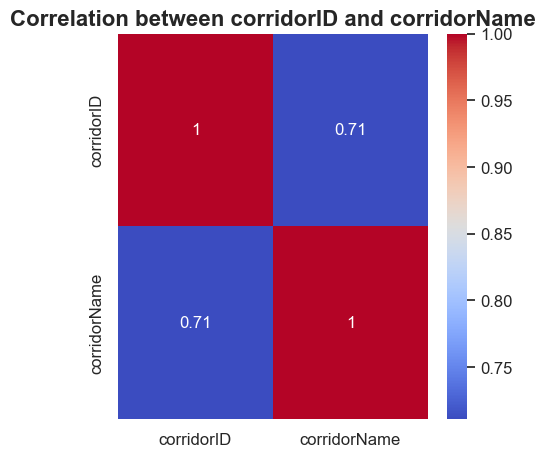

In [6]:
# Filter only corridorID and corridorName columns
cols = ['corridorID', 'corridorName']

# Missing value correlation between corridorID and corridorName
corr = df[cols].isnull().corr()

# Plot heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between corridorID and corridorName")
plt.show()

With a missing value correlation of 0.71, `corridorID` and `corridorName` exhibit a strong positive relationship, meaning that when one column contains a missing value, the other is highly likely to be missing as well. This also can be shown in the missing value heatmap below:

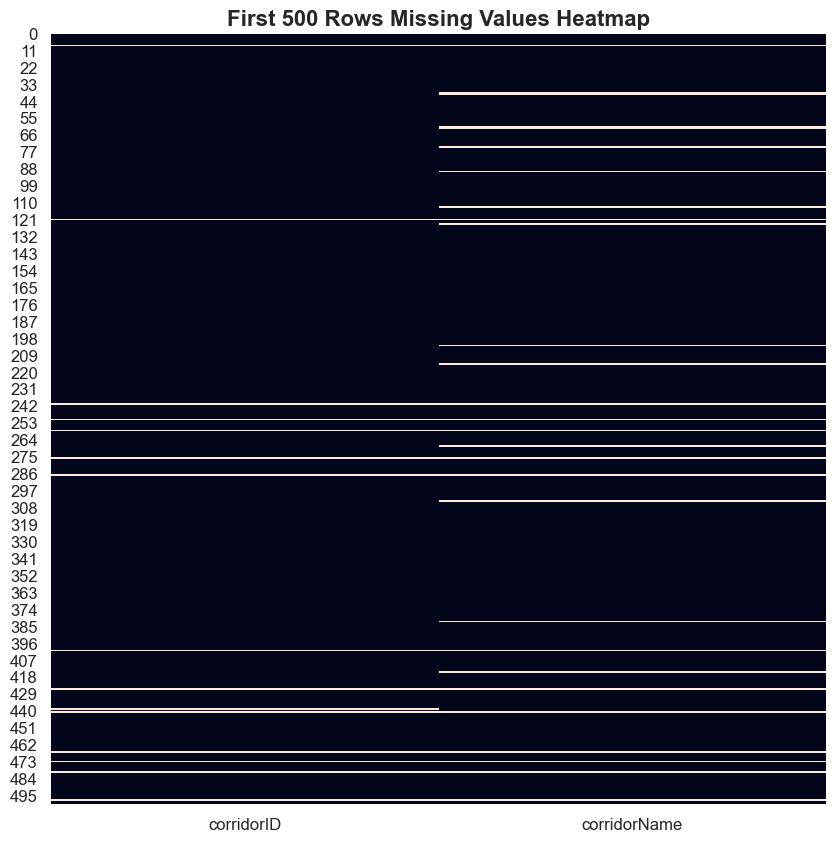

In [7]:
# Only the first 500 rows as sample data
sample_df = df[["corridorID", "corridorName"]].head(500)

# Plot heatmap for missing values
plt.figure(figsize=(10, 10))
sns.heatmap(sample_df.isna(), cbar=False)
plt.title("First 500 Rows Missing Values Heatmap")
plt.show()

The visualization above shows that although `corridorID` is mostly populated, `corridorName` is often missing. The next step is to verify whether any `corridorID` corresponds to more than one `corridorName`.

In [8]:
# Step 1: Keep corridorNames with multiple IDs
multiple_IDs = df.groupby('corridorName')['corridorID'].nunique(dropna=False)
multiple_names = multiple_IDs[multiple_IDs > 1].index.tolist()

# Step 2: Create DataFrame with count and full list of IDs (including NaN)
result = df[df['corridorName'].isin(multiple_names)] \
    .groupby('corridorName')['corridorID'] \
    .agg([
        ('count_IDs', lambda x: x.nunique(dropna=False)),
        ('list_IDs', lambda x: list(pd.unique(x)))
    ]) \
    .reset_index()

# Step 3: Sort based on count
result = result.sort_values(by='count_IDs', ascending=False)

# Step 4: Display
pd.set_option('display.expand_frame_repr', False)
print(result)

                                   corridorName  count_IDs        list_IDs
50                         Pinang Ranti - Pluit          3    [M9, 9, nan]
55                          Pulo Gadung - Monas          3    [2, M2, nan]
20          Kalideres - Bundaran HI via Veteran          3    [M3, 3, nan]
39                        Matraman Baru - Ancol          3    [5, nan, M5]
65            Ragunan - MH Thamrin via Semanggi          2       [6B, nan]
..                                          ...        ...             ...
31     Kampung Rambutan - Juanda via Pasar Baru          2       [7F, nan]
30                    Kampung Rambutan - Blok M          2       [7B, nan]
29               Kampung Rambutan - Bidara Cina          2        [7, nan]
28                 Kampung Melayu - Tanah Abang          2       [5F, nan]
100  Tongtek - Tebet Eco Park (TEP) - Cililitan          2  [JAK.43B, nan]

[101 rows x 3 columns]


From the output above, it can be observed that most `corridorName` values are associated with two IDs, where one of them is `NaN`, indicating missing data.

Only four corridor names are associated with three distinct IDs. Among these, two cases show inconsistencies in the ID format (e.g., the presence of an "M" prefix versus numeric-only IDs), suggesting potential data standardization issues.  According to the official Transjakarta route reference page: https://transjakarta.co.id/rute , there are no corridor IDs that officially use the prefix **"M"**. Therefore, corridorIDs that appear with an "M" prefix should be standardized by removing the letter prefix and retaining only the numeric component to ensure consistency in the dataset.

In [9]:
result_m = result[
    result['list_IDs'].apply(
        lambda x: any(str(i).startswith('M') for i in x if pd.notna(i))
    )
]

print(result_m)

                            corridorName  count_IDs      list_IDs
50                  Pinang Ranti - Pluit          3  [M9, 9, nan]
55                   Pulo Gadung - Monas          3  [2, M2, nan]
20   Kalideres - Bundaran HI via Veteran          3  [M3, 3, nan]
39                 Matraman Baru - Ancol          3  [5, nan, M5]
62                 Puri Beta 2 - Tendean          2    [M13, nan]
57          Pulo Gadung 2 - Dukuh Atas 2          2     [M4, nan]
94          Tanah Abang - St. Gondangdia          2    [M1H, nan]
89  Sunter Boulevard Barat - Penjaringan          2    [M12, nan]
5                          Blok M - Kota          2       [M1, 1]
1                           BKN - Blok M          2    [M7B, nan]
43                 PGC 2 - Tanjung Priok          2    [M10, nan]
32              Kampung Rambutan - Monas          2     [M7, nan]


In [10]:
df['corridorID'] = df['corridorID'].apply(
    lambda x: str(x)[1:] if isinstance(x, str) and x.startswith('M') else x
)

For corridor IDs containing `NaN`, the missing values can be imputed using the corresponding valid ID within the same `corridorName`.

In [11]:
def mapping_df(x, y):
    global mapping_dict
    mapped_df = df[[x, y]].drop_duplicates().dropna()
    mapping_dict = dict(zip(mapped_df[x], mapped_df[y]))
    return mapping_dict

In this section below, we will perform imputation for `corridorID`:

In [12]:
mapping_df("corridorName","corridorID")
df['corridorID'] = df['corridorName'].map(mapping_dict).fillna(df['corridorID'])

After that, we will perform imputation for `corridorName`:

In [13]:
mapping_df("corridorID","corridorName")
df['corridorName'] = df['corridorID'].map(mapping_dict).fillna(df['corridorName'])

Currently, the number of missing values in `corridorID` and `corridorName` has been reduced to 1,125 records.  

These 1,125 records will be dropped as they cannot be imputed or reconstructed based on the available information, making it impossible to assign valid values.

In [14]:
missing_data = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': (df.isna().mean() * 100).round(2)
})

missing_data[missing_data['missing_count'] > 0]

,missing_count,missing_percentage
corridorID,1125,2.97
corridorName,1125,2.97
tapInStops,1213,3.20
tapOutStops,2289,6.04
tapOutStopsName,1344,3.55
tapOutStopsLat,1344,3.55
tapOutStopsLon,1344,3.55
stopEndSeq,1344,3.55
tapOutTime,1344,3.55
payAmount,1007,2.66


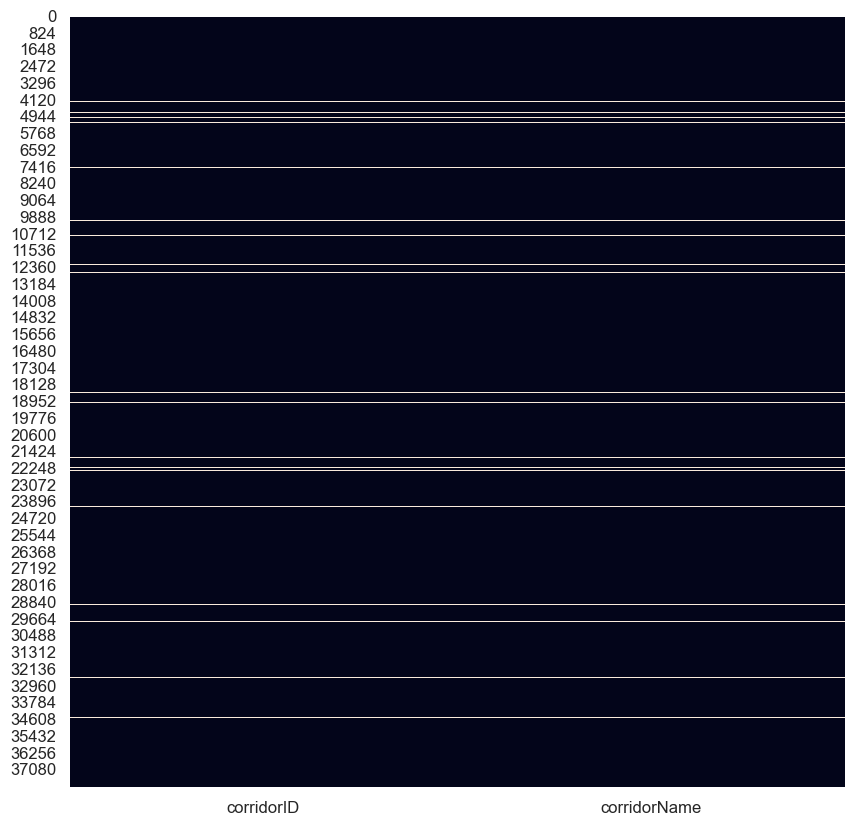

In [15]:
plt.figure(figsize=(10,10))
sns.heatmap(df[["corridorID","corridorName"]].isna(), cbar=False)
plt.show()

In [16]:
df = df.dropna(subset=['corridorID', 'corridorName'])

After dropping the incomplete records, there are no remaining missing values in `corridorID` and `corridorName`.

In [17]:
missing_data = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': (df.isna().mean() * 100).round(2)
})

missing_data[missing_data['missing_count'] > 0]

,missing_count,missing_percentage
tapInStops,1182,3.21
tapOutStops,2210,6.01
tapOutStopsName,1297,3.53
tapOutStopsLat,1297,3.53
tapOutStopsLon,1297,3.53
stopEndSeq,1297,3.53
tapOutTime,1297,3.53
payAmount,979,2.66


### **5.2 `tapInStops` and `tapOutStops`**

In [18]:
df[['tapInStops','tapOutStops']]

,tapInStops,tapOutStops
0,P00142,P00253
1,B01963P,B03307P
2,B00499P,B04962P
3,B05587P,B03090P
4,P00239,P00098
...,...,...
37895,P00261,P00228
37896,P00064,P00179
37897,B02873P,B00226P
37898,B02505P,B01787P


The `tapInStops` and `tapOutStops` columns are removed because they only contain identifiers and do not provide meaningful information for the analysis.

In [19]:
df.drop(columns=['tapInStops', 'tapOutStops'], inplace=True)

### **5.3 Relationships Among Tap-Out Variables**

The first step is to use a heatmap to examine the relationship between `tapOutStopsName`, `tapOutStopsLat`, `tapOutStopsLon`, `tapOutStopsLat`, `stopEndSeq`, and `tapOutTime`, as well as identify any missing mappings between them.

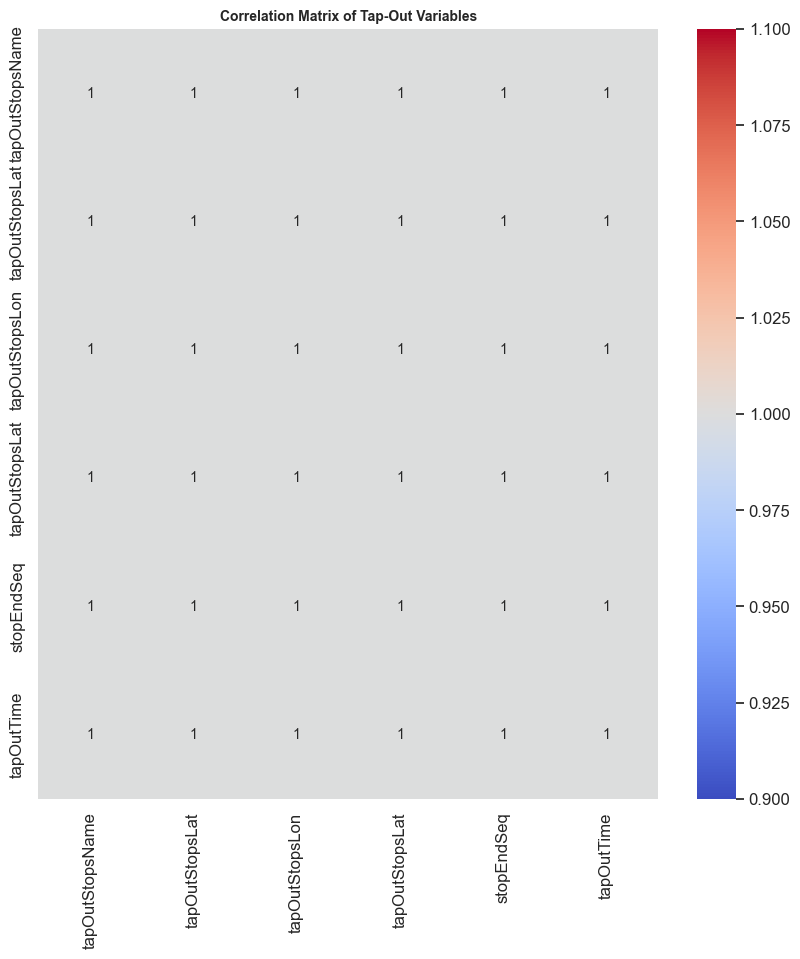

In [20]:
# Filter columns
cols = ['tapOutStopsName', 'tapOutStopsLat', 'tapOutStopsLon', 'tapOutStopsLat', 'stopEndSeq', 'tapOutTime']

# Missing value correlation
corr = df[cols].isnull().corr()

# Plot heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', annot_kws={'size': 10})
plt.title("Correlation Matrix of Tap-Out Variables", fontsize=10)
plt.show()

The correlation matrix shows perfect correlation (value = 1) across all tap-out variables in the dataset, indicating that missing values occur simultaneously. This suggests that the missingness is structural and originates from the same underlying process rather than occurring randomly. For better visualization, the heatmap is shown below.

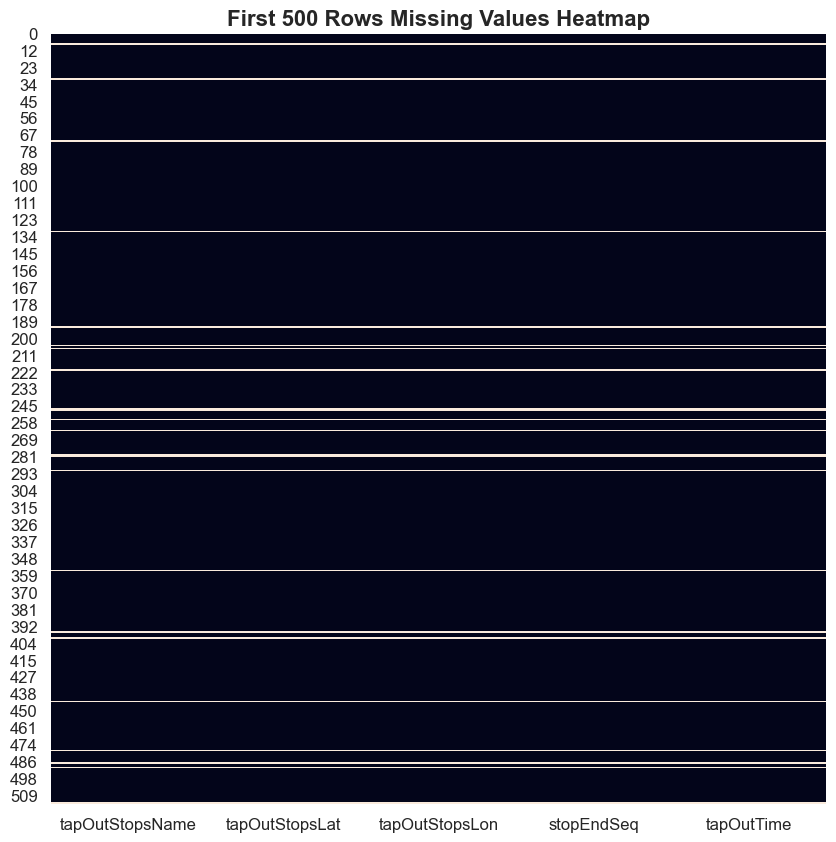

In [21]:
# Only the first 500 rows as sample data
sample_df = df[["tapOutStopsName","tapOutStopsLat","tapOutStopsLon","stopEndSeq","tapOutTime"]].head(500)

# Plot heatmap for missing values
plt.figure(figsize=(10, 10))
sns.heatmap(sample_df.isna(), cbar=False)
plt.title("First 500 Rows Missing Values Heatmap")
plt.show()

Therefore, the missing tap-out data will be removed based on several considerations:
1. The proportion of missing data is relatively small (3.53%) and is unlikely to introduce significant bias. 
2. The correlation matrix shows perfect correlation (value = 1) across all tap-out variables, and the missing values heatmap confirms structural missingness. 
3. Based on the [Peraturan Gubernur DKI Jakarta No. 2 Tahun 2024](https://peraturan.bpk.go.id/Details/281553/pergub-prov-dki-jakarta-no-2-tahun-2024), all passengers are required to use electronic ticketing systems by tapping in and tapping out. This mechanism is essential for trip validation and fare integration within the public transport system. Therefore, trips without tap-out records are considered incomplete and cannot be reliably used for analysis.

By retaining 96.47% of complete trips, this approach ensures all four analytical objectives are built on clean, representative data.

In [22]:
df.shape

(36775, 20)

In [23]:
df = df.dropna(subset=[
    "tapOutStopsName",
    "tapOutStopsLat",
    "tapOutStopsLon",
    "stopEndSeq",
    "tapOutTime"
])

df.shape



(35478, 20)

After removing rows with missing values in tap-out-related variables, the dataset size decreased from 36,775 to 35,478 records. A total of 1,297 rows (approximately 3.53%) were removed.

### **5.4 Missing Data in `payAmount` Column**



At this stage, we will first check what the unique values are in the `payAmount` column.

In [24]:
df['payAmount'].unique()

array([ 3500., 20000.,    nan,     0.])

The `payAmount` column contains four unique values: 0, 3,500, 20,000, and NaN.

Based on the official Transjakarta fare policy:
- **Rp3,500**: Regular fare for BRT and integrated non-BRT services.
- **Rp0**: Mikrotrans service, which is free of charge for passengers.
- **Rp20,000**: Royaltrans premium service with additional facilities.
- **NaN**: Missing or unrecorded payment information that requires further investigation.

In [25]:
df[df['payAmount'].isna()]['corridorID'].value_counts()

corridorID
7B         299
JAK.48A    240
1H         165
JAK.48B    148
3H          89
Name: count, dtype: int64

Based on the [Official Transjakarta route information](https://transjakarta.co.id/rute), corridor codes such as **7B, 1H, and 3H** are part of the BRT service and corridors that start with **"JAK"** belong to the Mikrotrans service.

Therefore, the fare structure is defined as follows:
- **Mikrotrans**: Rp0
- **BRT**: Rp3,500

In [26]:
na_payAmount = df['payAmount'].isna()

df.loc[na_payAmount, 'payAmount'] = np.where(
    df.loc[na_payAmount, 'corridorID'].astype(str).str.startswith('JAK'),
    0,
    3500
)

The dataset `df` is now complete with no missing values and is ready for further analysis.

In [27]:
df.isna().sum()

transID             0
payCardID           0
payCardBank         0
payCardName         0
payCardSex          0
payCardBirthDate    0
corridorID          0
corridorName        0
direction           0
tapInStopsName      0
tapInStopsLat       0
tapInStopsLon       0
stopStartSeq        0
tapInTime           0
tapOutStopsName     0
tapOutStopsLat      0
tapOutStopsLon      0
stopEndSeq          0
tapOutTime          0
payAmount           0
dtype: int64

---

## **6. Data Transformation**

### **6.1 Select Relevant Columns**

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35478 entries, 0 to 37899
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           35478 non-null  object 
 1   payCardID         35478 non-null  int64  
 2   payCardBank       35478 non-null  object 
 3   payCardName       35478 non-null  object 
 4   payCardSex        35478 non-null  object 
 5   payCardBirthDate  35478 non-null  int64  
 6   corridorID        35478 non-null  object 
 7   corridorName      35478 non-null  object 
 8   direction         35478 non-null  float64
 9   tapInStopsName    35478 non-null  object 
 10  tapInStopsLat     35478 non-null  float64
 11  tapInStopsLon     35478 non-null  float64
 12  stopStartSeq      35478 non-null  int64  
 13  tapInTime         35478 non-null  object 
 14  tapOutStopsName   35478 non-null  object 
 15  tapOutStopsLat    35478 non-null  float64
 16  tapOutStopsLon    35478 non-null  float64
 17

Next step is change data types and format:




In [29]:
# Integer columns
df['direction'] = df['direction'].astype('int64')
df['stopEndSeq'] = df['stopEndSeq'].astype('int64')
df['payAmount'] = df['payAmount'].astype('int64')

# Datetime columns
df['tapInTime'] = pd.to_datetime(df['tapInTime'])
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'])

# Result
df.dtypes

transID                     object
payCardID                    int64
payCardBank                 object
payCardName                 object
payCardSex                  object
payCardBirthDate             int64
corridorID                  object
corridorName                object
direction                    int64
tapInStopsName              object
tapInStopsLat              float64
tapInStopsLon              float64
stopStartSeq                 int64
tapInTime           datetime64[ns]
tapOutStopsName             object
tapOutStopsLat             float64
tapOutStopsLon             float64
stopEndSeq                   int64
tapOutTime          datetime64[ns]
payAmount                    int64
dtype: object

In [30]:
df.head().T

,0,1,2,3,4
transID,EIIW227B8L34VB,LGXO740D2N47GZ,DJWR385V2U57TO,JTUZ800U7C86EH,VMLO535V7F95NJ
payCardID,180062659848800,4885331907664776,4996225095064169,639099174703,570928206772
payCardBank,emoney,dki,dki,flazz,flazz
payCardName,Bajragin Usada,Gandi Widodo,Emong Wastuti,Surya Wacana,Embuh Mardhiyah
payCardSex,M,F,F,F,M
payCardBirthDate,2008,1997,1992,1978,1982
corridorID,5,6C,R1A,11D,12
corridorName,Matraman Baru - Ancol,Stasiun Tebet - Karet via Patra Kuningan,Pantai Maju - Kota,Pulo Gebang - Pulo Gadung 2 via PIK,Sunter Boulevard Barat - Penjaringan
direction,1,0,0,0,0
tapInStopsName,Pal Putih,Kemenkes 2,Gg. Kunir II,Taman Elok 1,Sunter Boulevard Barat


Then the `payCardSex` values are transformed from M and F into Male and Female.

In [31]:
df['payCardSex'] = df['payCardSex'].replace({
    'M': 'Male',
    'F': 'Female'
})

After that, the new feature `age` is created by calculating the difference between 2023 and `payCardBirthYear`

In [32]:
df['age'] = 2023 - df['payCardBirthDate']

df[['payCardBirthDate','age']].head()

,payCardBirthDate,age
0,2008,15
1,1997,26
2,1992,31
3,1978,45
4,1982,41


Users are categorized into three age groups: School Age (<17), Working Age (18–59), and Elderly (>59) to facilitate demographic segmentation.

In [33]:
df['ageCategory'] = (
                    np.where(df['age'] <= 17, 'School Age', 
                    np.where(df['age'] <= 59, 'Working Age',
                    'Elderly'     
                    )))

df['ageCategory'] = df['ageCategory'].astype('category')

ageOrder = ['School Age', 'Working Age', 'Elderly']

df['ageCategory'] = pd.Categorical(
    df['ageCategory'],
    categories=ageOrder,
    ordered=True
)

df['ageCategory'].unique()

['School Age', 'Working Age', 'Elderly']
Categories (3, object): ['School Age' < 'Working Age' < 'Elderly']

Another new feature, `trip_duration`, is derived by computing the time difference between tap-in and tap-out timestamps.

In [34]:
# Trip Duration in Minutes
df['tripDuration'] = ((df['tapOutTime'] - df['tapInTime']).dt.total_seconds() / 60).round().astype('int')

# Result
df.dtypes

transID                     object
payCardID                    int64
payCardBank                 object
payCardName                 object
payCardSex                  object
payCardBirthDate             int64
corridorID                  object
corridorName                object
direction                    int64
tapInStopsName              object
tapInStopsLat              float64
tapInStopsLon              float64
stopStartSeq                 int64
tapInTime           datetime64[ns]
tapOutStopsName             object
tapOutStopsLat             float64
tapOutStopsLon             float64
stopEndSeq                   int64
tapOutTime          datetime64[ns]
payAmount                    int64
age                          int64
ageCategory               category
tripDuration                 int64
dtype: object

The `transactionDay` feature is created to enable analysis of usage patterns across different days of the week.

In [35]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df['transactionDay'] = pd.Categorical(
    df['tapInTime'].dt.day_name(),
    categories=day_order,
    ordered=True
)

df['transactionDay'].head()

0    Monday
1    Monday
2    Monday
3    Monday
4    Monday
Name: transactionDay, dtype: category
Categories (7, object): ['Monday' < 'Tuesday' < 'Wednesday' < 'Thursday' < 'Friday' < 'Saturday' < 'Sunday']

The `service_type` feature is created to enable comparison of usage patterns across different service categories.

In [36]:
df['serviceType'] = df['payAmount'].map({
    0: 'Mikrotrans',
    3500: 'BRT',
    20000: 'Royaltrans'
})

Based on the [Official Transjakarta route information](https://transjakarta.co.id/rute), corridor codes starting with "BW" are classified under the Wisata service category.


In [37]:
df["serviceType"] = np.where(
    df["corridorID"].str.startswith("BW"),
    "Wisata",
    df["serviceType"]
)

Based on the [Official Transjakarta route information](https://transjakarta.co.id/rute), there's 64 corridors are classifiedd under the Angkutan Pengumpan service category.

In [38]:
angkutanPengumpan_list = [
    "8K", "8E", "7Q", "6U", "7W", "7U", "7C", "7V", "7R", "7T", 
    "6Q", "6W", "2Q", "2B", "8D", "11Q", "5M", "5F", "7B", "7E", 
    "9E", "8N", "8C", "12A", "7A", "1M", "14A", "1A", "9H", "9D", 
    "6T", "6K", "4C", "1C", "4F", "12B", "7P", "1E", "4K", "2M", 
    "11D", "6N", "5N", "1Q", "1P", "6H", "1R", "2P", "3E", "12P", 
    "6C", "11W", "6M", "4B", "1F", "1B", "1H", "5B", "6D", "3D", 
    "1N", "8M", "14B", "7D"
]


In [39]:
df.loc[df['corridorID'].isin(angkutanPengumpan_list), 'serviceType'] = 'Angkutan Pengumpan'

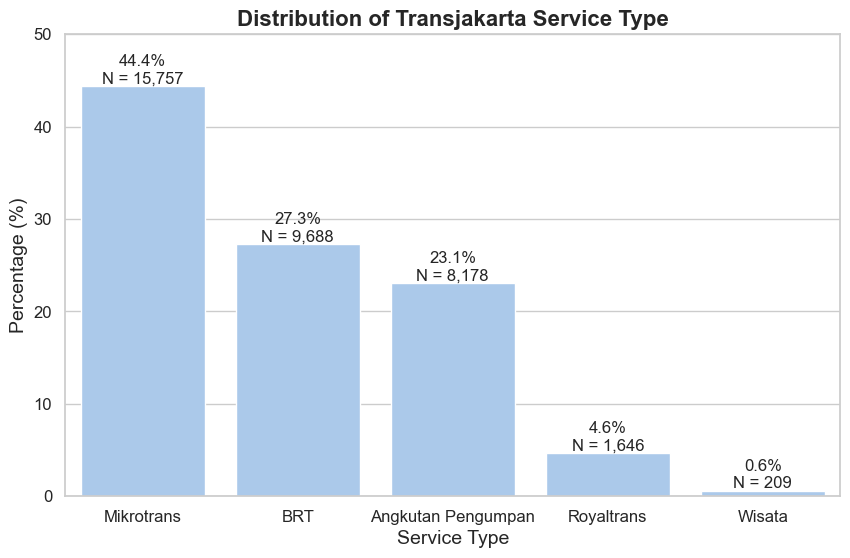

In [40]:
count = df['serviceType'].value_counts()
pct = df['serviceType'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(x=pct.index, y=pct.values, ax=ax)

for i, (p, n) in enumerate(zip(pct.values, count.values)):
    ax.text(
        i,
        p,
        f'{p:.1f}%\nN = {n:,}',
        ha='center',
        va='bottom',
        fontsize=12
    )

ax.set_title('Distribution of Transjakarta Service Type')
ax.set_xlabel('Service Type')
ax.set_ylabel('Percentage (%)')

ax.set_ylim(0, 50)

plt.show()

Based on the data, Transjakarta services can be grouped into three categories according to their function and target users:
- Core services (Mikrotrans, BRT, Angkutan Pengumpan): these dominate total ridership and serve as the backbone of daily commuting
- Premium services (Royaltrans): these have lower ridership but cater to a specific segment seeking comfort and convenience
- Tourism services (Wisata): these have the smallest share and exhibit different usage patterns

To gain a clearer understanding of user behavior, the analysis will be conducted separately for each category. Therefore, we will first create `serviceCategory` for each service.

In [41]:
mapping = {
    'BRT': 'Core Service',
    'Mikrotrans': 'Core Service',
    'Angkutan Pengumpan': 'Core Service',
    'Royaltrans': 'Premium Service',
    'Wisata': 'Tourism Service'
}

df['serviceCategory'] = df['serviceType'].map(mapping)

The dataset columns are reordered to match the required structure for analysis.

In [42]:
new_order = [
    # 1. Customer Identifier
    'transID', 'payCardID', 'payCardBank', 'payCardName', 'payCardSex', 'payCardBirthDate', 'age', 'ageCategory',

    # 2. Trip Identifier
    'corridorID', 'corridorName', 'serviceType', 'serviceCategory', 'direction', 'tripDuration', 'transactionDay',

    # 4. Tap In Identifier
    'tapInStopsName', 'tapInStopsLat', 'tapInStopsLon', 'stopStartSeq', 'tapInTime',

    # 5. Tap Out Identifier
    'tapOutStopsName', 'tapOutStopsLat', 'tapOutStopsLon', 'stopEndSeq', 'tapOutTime',

    # 6. Pay
    'payAmount'
    
]

df = df[new_order]

df.head(5).T

,0,1,2,3,4
transID,EIIW227B8L34VB,LGXO740D2N47GZ,DJWR385V2U57TO,JTUZ800U7C86EH,VMLO535V7F95NJ
payCardID,180062659848800,4885331907664776,4996225095064169,639099174703,570928206772
payCardBank,emoney,dki,dki,flazz,flazz
payCardName,Bajragin Usada,Gandi Widodo,Emong Wastuti,Surya Wacana,Embuh Mardhiyah
payCardSex,Male,Female,Female,Female,Male
payCardBirthDate,2008,1997,1992,1978,1982
age,15,26,31,45,41
ageCategory,School Age,Working Age,Working Age,Working Age,Working Age
corridorID,5,6C,R1A,11D,12
corridorName,Matraman Baru - Ancol,Stasiun Tebet - Karet via Patra Kuningan,Pantai Maju - Kota,Pulo Gebang - Pulo Gadung 2 via PIK,Sunter Boulevard Barat - Penjaringan


After completing the data cleaning and transformation process, the final dataset is saved in Excel or CSV format for subsequent analysis and reporting purposes.

In [43]:
df.to_csv("transjakarta_cleaned.csv")

Below is a description of the columns found in the Transjakarta data after cleaning:


| **No.** | **Column Name**        | **Column Description** |
|-----|------------------|-------------------|
| 1.  | transID          | Unique transaction ID for every transaction. |
| 2.  | payCardID        | The main customer identifier. |
| 3.   | payCardBank      | The bank that issued the customer’s payment card. |
| 4.   | payCardName      | The name of the cardholder. |
| 5.   | payCardSex       | The cardholder’s gender. |
| 6.   | payCardBirthDate | The cardholder’s year of birth. |
| 7.   | age              | The calculated age of the cardholder based on birth year. |
| 8.   | ageCategory      | The age group classification of the cardholder. |
| 9.   | corridorID       | The corridor identifier. |
| 10.  | corridorName     | The route name, often indicating the starting and ending points. |
| 11.  | serviceType      | Type of service. |
| 12.  | serviceCategory  | Service category of service. |
| 13.  | direction        | The trip direction, with 0 representing outbound and 1 representing return. |
| 14.  | tripDuration     | Duration of the trip in minutes or hours. |
| 15.  | transactionDay   | The day when the transaction occurred. |
| 16.  | tapInStopsName   | The name of the tap-in (entry) stop. |
| 17.  | tapInStopsLat    | Latitude coordinate of the tap-in stop. |
| 18.  | tapInStopsLon    | Longitude coordinate of the tap-in stop. |
| 19.  | stopStartSeq     | The sequence number of the tap-in stop within the route. |
| 20.  | tapInTime        | The date and time when the passenger taps in. |
| 21.  | tapOutStopsName  | The name of the tap-out (exit) stop. |
| 22.  | tapOutStopsLat   | Latitude coordinate of the tap-out stop. |
| 23.  | tapOutStopsLon   | Longitude coordinate of the tap-out stop. |
| 24.  | stopEndSeq       | The sequence number of the tap-out stop within the route. |
| 25.  | tapOutTime       | The date and time when the passenger taps out. |
| 26.  | payAmount        | The fare paid by the customer, which may be zero for free trips or a positive value for paid trips. |


---

## **7. Analysis**

### **7.1 User Demographics**

#### **7.1.1 Age Category**

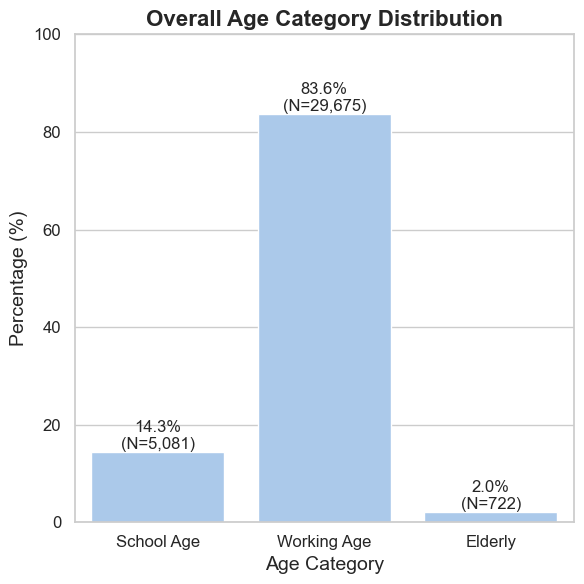

In [44]:
fig, ax = plt.subplots(figsize=(6,6))

ageOrder = ['School Age', 'Working Age', 'Elderly']

count = df['ageCategory'].value_counts().reindex(ageOrder, fill_value=0)
pct = (count / count.sum()) * 100

sns.barplot(x=ageOrder, y=pct.values, ax=ax)

for i in range(len(ageOrder)):
    ax.text(
        i,
        pct.values[i],
        f"{pct.values[i]:.1f}%\n(N={count.values[i]:,})",
        ha='center',
        va='bottom'
    )

ax.set_title("Overall Age Category Distribution")
ax.set_xlabel("Age Category")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

The majority of Transjakarta users are from the working-age group (83.6%), indicating that the service is primarily utilized by the productive-age population.

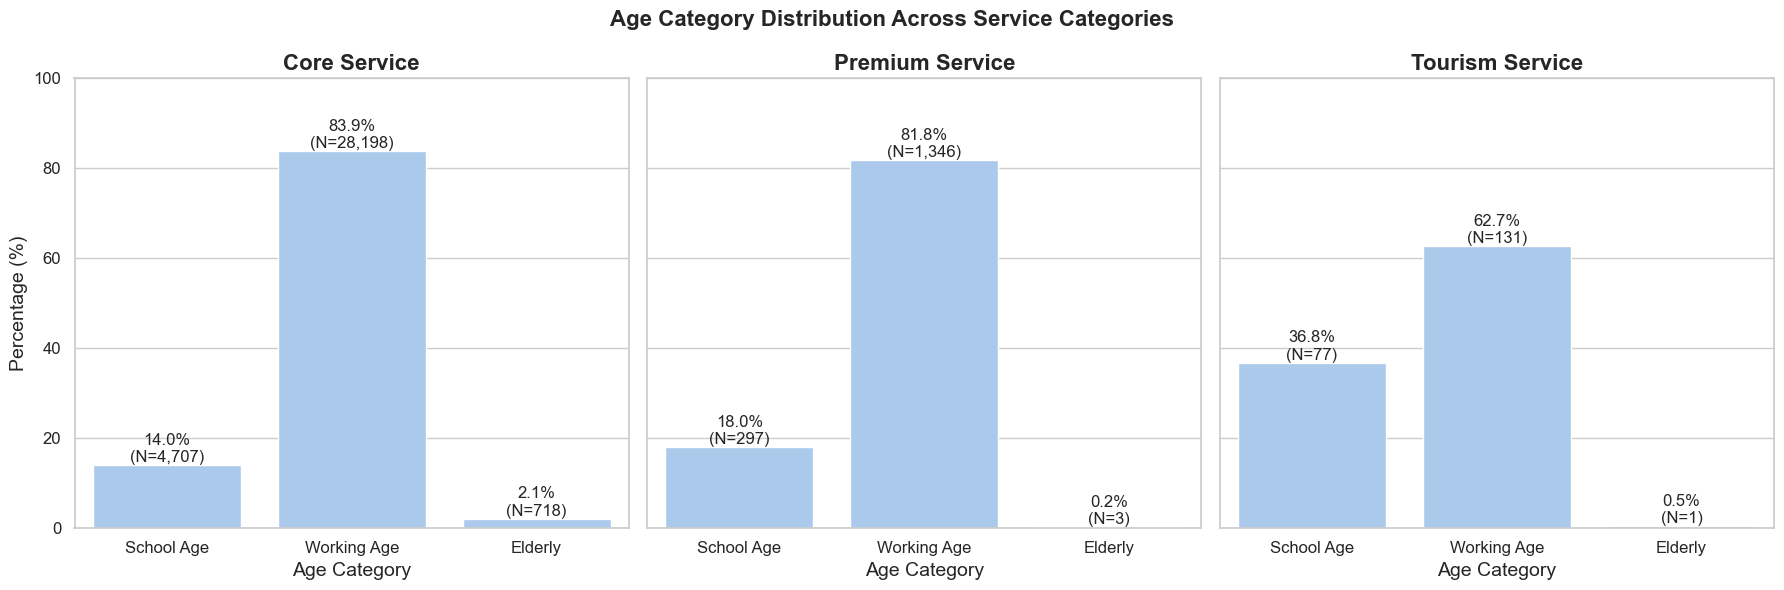

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

ageOrder = ['School Age', 'Working Age', 'Elderly']

for ax, (title, data) in zip(
    axes,
    df.groupby('serviceCategory')
):
    
    count = data['ageCategory'].value_counts().reindex(ageOrder)
    pct = (count / count.sum()) * 100

    sns.barplot(x=ageOrder, y=pct.values, ax=ax)

    for i in range(len(ageOrder)):
        ax.text(
            i,
            pct.values[i],
            f"{pct.values[i]:.1f}%\n(N={count.values[i]:,})",
            ha='center',
            va='bottom'
        )

    ax.set_title(title)
    ax.set_xlabel('Age Category')
    ax.set_ylabel('Percentage (%)')

    ax.set_ylim(0, 100)

plt.suptitle("Age Category Distribution Across Service Categories",
             size=16, y=0.98, fontweight='semibold')

plt.tight_layout()
plt.show()

From the data above, it is known that the working age group uses all services the most. Meanwhile, the school age group uses tourism service the most, while the elderly use core service the most. The elderly rarely use tourism and premium services, indicating that they seldom take long trips.

#### **7.1.2 Gender Distribution**

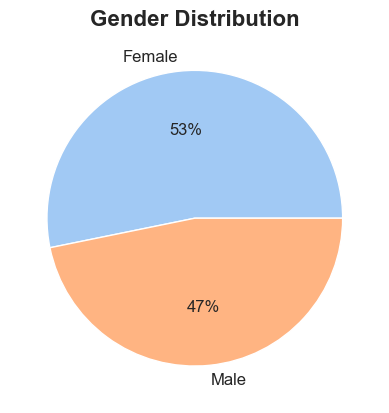

In [46]:
count = df['payCardSex'].value_counts(normalize=True)

plt.pie(count, labels=count.index, autopct='%.0f%%')
plt.title('Gender Distribution')
plt.show()


Based on gender distribution, 53% of Transjakarta service users are female, with males accounting for the remaining 47%.

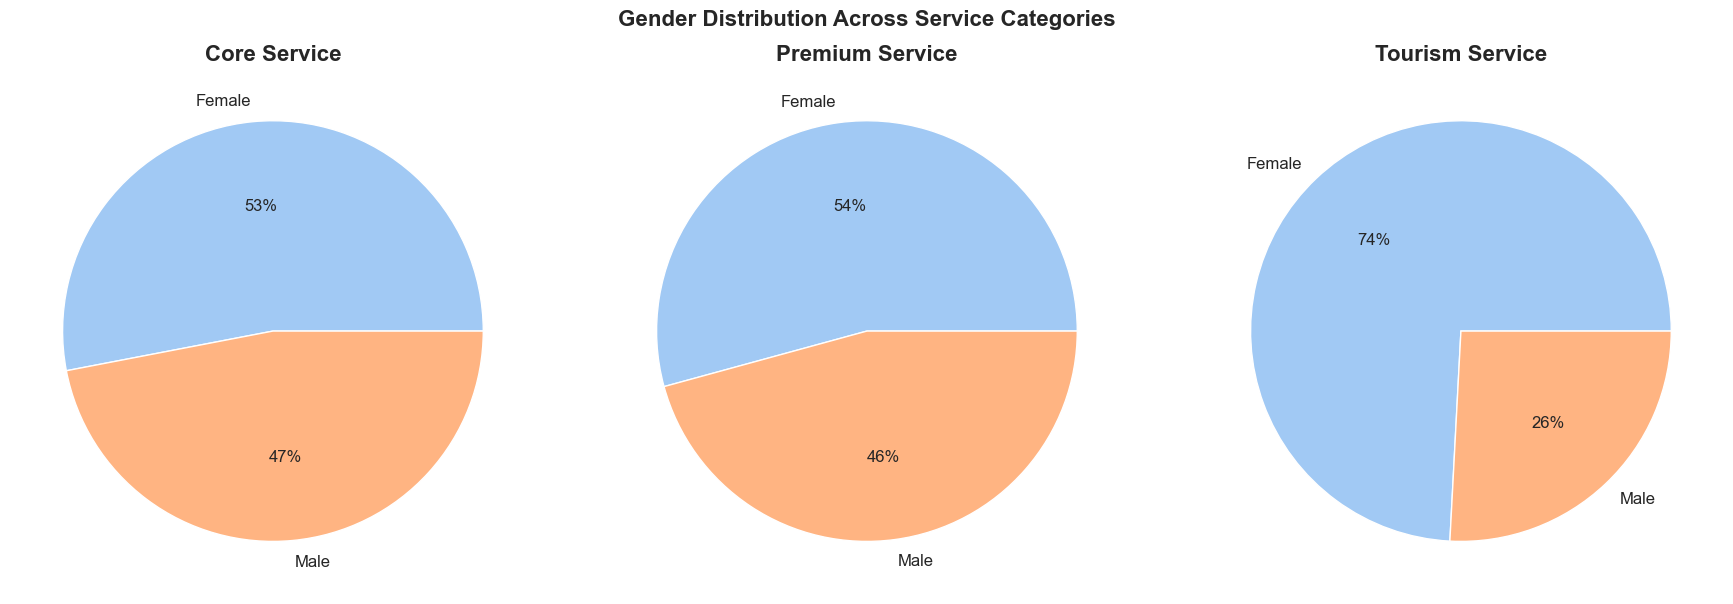

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, df_) in zip(
    axes,
    df.groupby('serviceCategory')
):
    count = df_['payCardSex'].value_counts(normalize=True)

    ax.pie(
        count,
        labels=count.index,
        autopct='%.0f%%'
    )

    ax.set_title(name)

plt.suptitle("Gender Distribution Across Service Categories",
             size=16, y=1.005, fontweight='semibold')

plt.tight_layout()
plt.show()

A similar gender balance is seen in core and premium services, but tourism services stand out with a significant female majority of 74%

#### **7.1.4 Payment Type**

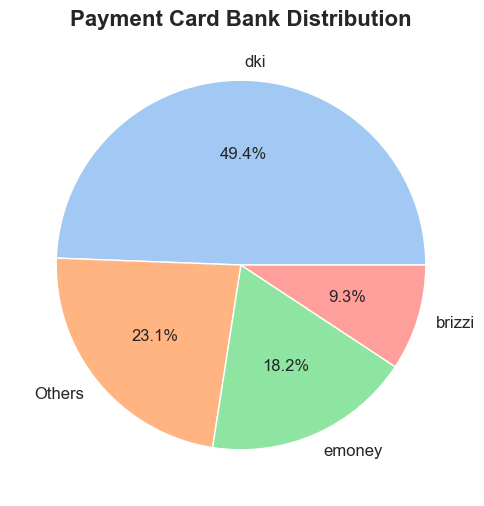

In [48]:
top_banks = df['payCardBank'].value_counts().head(3).index

df['bank_grouped'] = df['payCardBank'].apply(
    lambda x: x if x in top_banks else 'Others'
)

bank_counts = df['bank_grouped'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    bank_counts.values,
    labels=bank_counts.index,
    autopct='%1.1f%%'
)

plt.title('Payment Card Bank Distribution')
plt.show()

Bank DKI dominates the payment ecosystem with 49.4% share, indicating strong user dependency or system preference. eMoney follows as a secondary option with 18.2%, while Brizzi remains a niche player at 9.3%. The relatively large in Others category (23.1%) suggests a fragmented payment landscape, indicating potential opportunities for consolidation or strategic partnerships.

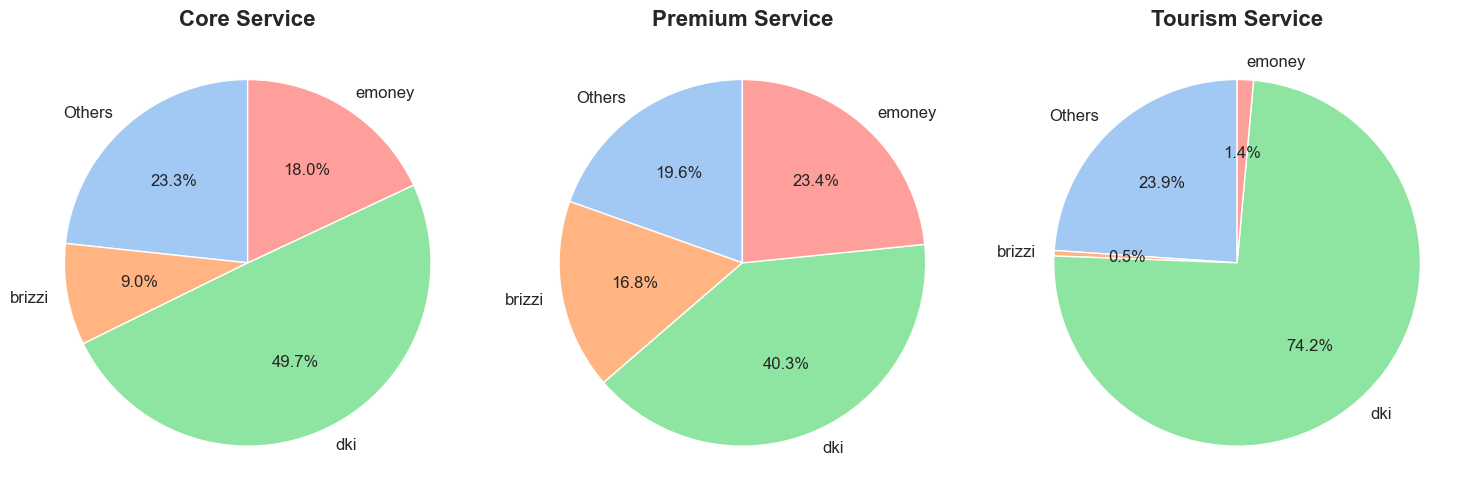

In [49]:
bank_service_clean = pd.crosstab(
    df['serviceCategory'],
    df['bank_grouped'],
    normalize='index'
) * 100

bank_service_clean

service_types = bank_service_clean.index

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, st in enumerate(service_types):
    axes[i].pie(
        bank_service_clean.loc[st],
        labels=bank_service_clean.columns,
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(st)

plt.tight_layout()
plt.show()

Bank DKI dominates across all service categories, especially in Tourism Service where it accounts for over 74% of transactions, indicating strong ecosystem dependency. Premium Service shows the most balanced payment distribution, suggesting higher user flexibility and competition among payment providers. Meanwhile, Core Service remains moderately diversified, with DKI still leading but not as dominant as in Tourism.

### **7.2 Trip Timing**

#### **7.2.1 Trip Timing Across April 2023**

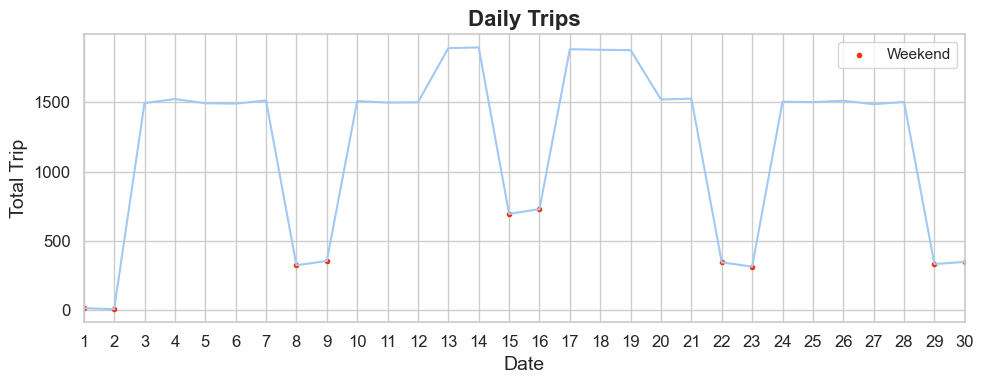

In [50]:
df['transactionDate'] = df['tapInTime'].dt.day
df['weekday'] = df['tapInTime'].dt.day_name()

count = df.groupby(['transactionDate', 'weekday']).size().reset_index(name='count')

count['isWeekend'] = count['weekday'].isin(['Saturday', 'Sunday'])

plt.figure(figsize=(10,4))

sns.lineplot(data=count, x='transactionDate', y='count')

plt.scatter(
    count[count['isWeekend']]['transactionDate'],
    count[count['isWeekend']]['count'],
    color='#F4320B',
    label='Weekend',
    marker='.'
)

plt.title("Daily Trips")
plt.xlabel("Date")
plt.ylabel("Total Trip")

plt.xlim(1, 30)
plt.xticks(range(1, 31))

plt.legend()

plt.tight_layout()
plt.show()


Based on the data, demand for all Transjakarta services drops significantly on weekends (shown by red dots). This suggests that Transjakarta is primarily used for routine mobility, including commuting to work and school.

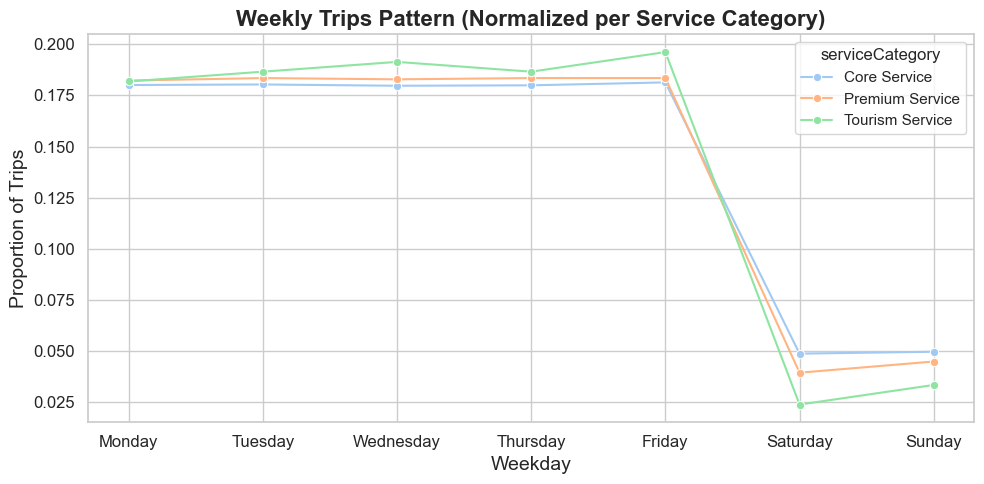

In [ ]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# aggregate
count = (
    df.groupby(['serviceCategory', 'weekday'], observed=True)
    .size()
    .reset_index(name='count')
)

# normalize per serviceCategory
count['pct'] = count['count'] / count.groupby('serviceCategory')['count'].transform('sum')

# set the weekday order
count['weekday'] = pd.Categorical(
    count['weekday'],
    categories=weekday_order,
    ordered=True
)

count = count.sort_values(['serviceCategory', 'weekday'])

plt.figure(figsize=(10,5))

sns.lineplot(
    data=count,
    x='weekday',
    y='pct',
    hue='serviceCategory',
    marker='o',
    sort=False
)

plt.title("Weekly Trips Pattern (Normalized per Service Category)")
plt.xlabel("Weekday")
plt.ylabel("Proportion of Trips")

plt.tight_layout()
plt.show()

A consistent decline in trip volume is observed across all service categories during weekends, indicating that demand is primarily driven by weekday activities

#### **7.2.2 Peak Hours**

In [53]:
def compute_hourly_peak(df):
    
    # Create a continuous hourly time range from the dataset coverage
    all_hours = pd.date_range(
        df['tapInTime'].min().floor('h'),   # start time rounded down to nearest hour
        df['tapOutTime'].max().ceil('h'),   # end time rounded up to nearest hour
        freq='h'                            # hourly frequency
    )

    hourly_count = []

    # Loop through each hour to calculate active trips
    for hour in all_hours:
        
        # A trip is considered active if:
        # - it has already started (tapInTime <= hour)
        # - and has not ended yet (tapOutTime > hour)
        count = ((df['tapInTime'] <= hour) & (df['tapOutTime'] > hour)).sum()
        
        hourly_count.append(count)

    # Combine results into a dataframe
    hourly_df = pd.DataFrame({
        'hour': all_hours,
        'count': hourly_count
    })

    # Extract only hour part (0–23) from timestamp
    hourly_df['hour_only'] = hourly_df['hour'].dt.hour

    # Aggregate: average active trips per hour of day
    overall_peak = (
        hourly_df
        .groupby('hour_only')['count']
        .mean()
        .reset_index()
    )

    # Return final result for plotting
    return overall_peak

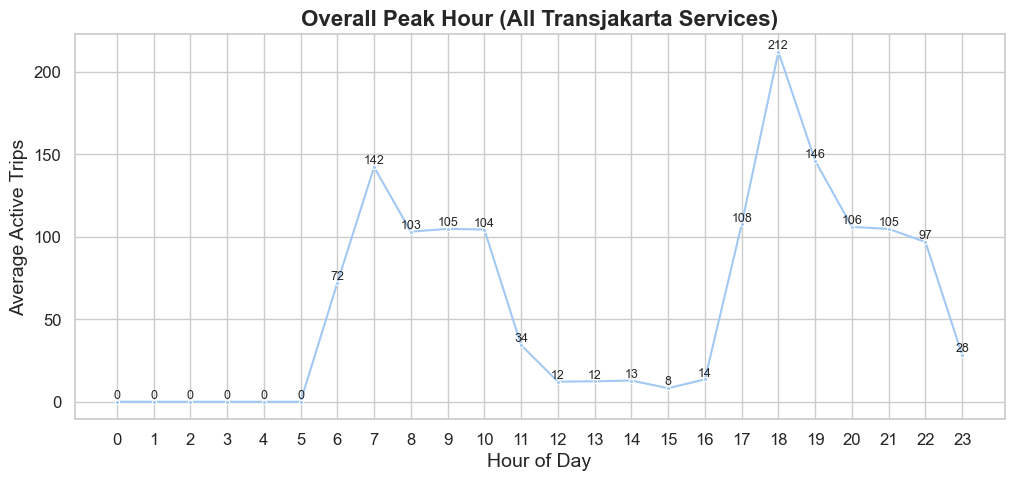

In [54]:
overall_peak = compute_hourly_peak(df)

plt.figure(figsize=(12,5))

ax = sns.lineplot(
    data=overall_peak,
    x='hour_only',
    y='count',
    marker='.'
)

# data labels
for x, y in zip(overall_peak['hour_only'], overall_peak['count']):
    ax.text(
        x,
        y,
        f'{y:.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(range(0, 24))
plt.title('Overall Peak Hour (All Transjakarta Services)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Active Trips')
plt.grid(True)

plt.show()

The graph above shows that average active trips peak around 7 AM and 6 PM across all Transjakarta services.

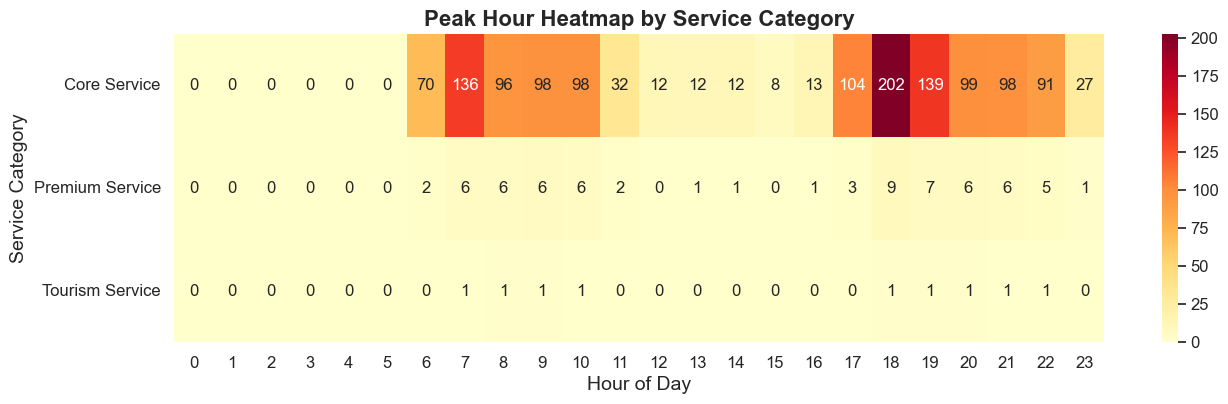

In [55]:
result_list = []

for name, df_part in df.groupby('serviceCategory'):
    temp = compute_hourly_peak(df_part)
    temp['serviceCategory'] = name
    result_list.append(temp)

final_df = pd.concat(result_list)

plt.figure(figsize=(15,4))

heatmap_df = final_df.pivot(
    index='serviceCategory',
    columns='hour_only',
    values='count'
)

sns.heatmap(
    heatmap_df,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f'
)

plt.title('Peak Hour Heatmap by Service Category')
plt.xlabel('Hour of Day')
plt.ylabel('Service Category')

plt.show()

Peak hours are primarily dominated by Core Service, occurring in the morning from 06:00–10:00 and in the evening from 17:00–19:59. In contrast, Premium Service and Tourism Service remain relatively stable, without any significant surge patterns.

### **7.3 Trip Frequency**

In [56]:
def classify(x):
    if x == 1:
        return 'One-time'
    elif x <= 5:
        return 'Occasional'
    else:
        return 'Frequent'

user_freq = df.groupby(['payCardID', 'serviceCategory'])['transID'].count().reset_index(name='tripCount')
user_freq['segment'] = user_freq['tripCount'].apply(classify)

user_freq

,payCardID,serviceCategory,tripCount,segment
0,60403675436,Core Service,38,Frequent
1,60404498697,Core Service,37,Frequent
2,60417020934,Core Service,4,Occasional
3,60421208343,Core Service,3,Occasional
4,60421208343,Premium Service,1,One-time
...,...,...,...,...
2091,4980316891349967240,Core Service,3,Occasional
2092,4980564692107508708,Core Service,13,Frequent
2093,4986663118222525457,Core Service,38,Frequent
2094,4995586292967989635,Core Service,4,Occasional


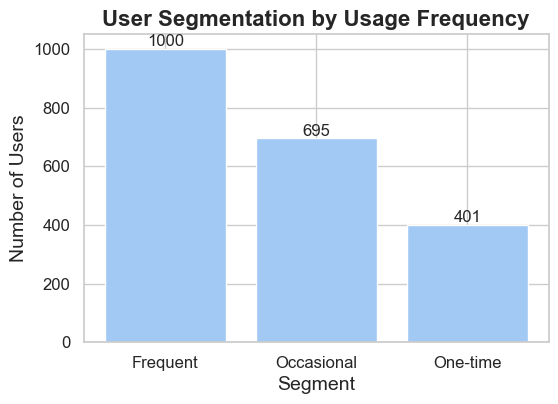

In [57]:
segment_counts = user_freq['segment'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(segment_counts.index, segment_counts.values)

for i, v in enumerate(segment_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.title('User Segmentation by Usage Frequency')
plt.xlabel('Segment')
plt.ylabel('Number of Users')
plt.show()

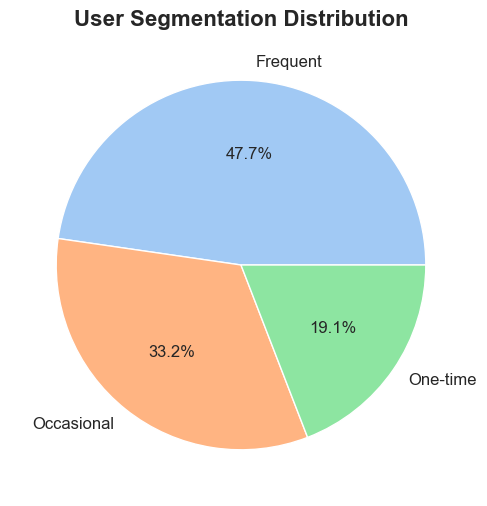

In [58]:
segment_pct = user_freq['segment'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%')
plt.title('User Segmentation Distribution')
plt.show()

Based on the chart, nearly half of users (47.7%) are regular Transjakarta riders, indicating a solid loyal base. However, more than half of all users are not frequent, consisting of 33.2% occasional and 19.1% one-time users. The occasional segment (33.2%) represents the biggest opportunity to convert into frequent users through incentives or service improvements.

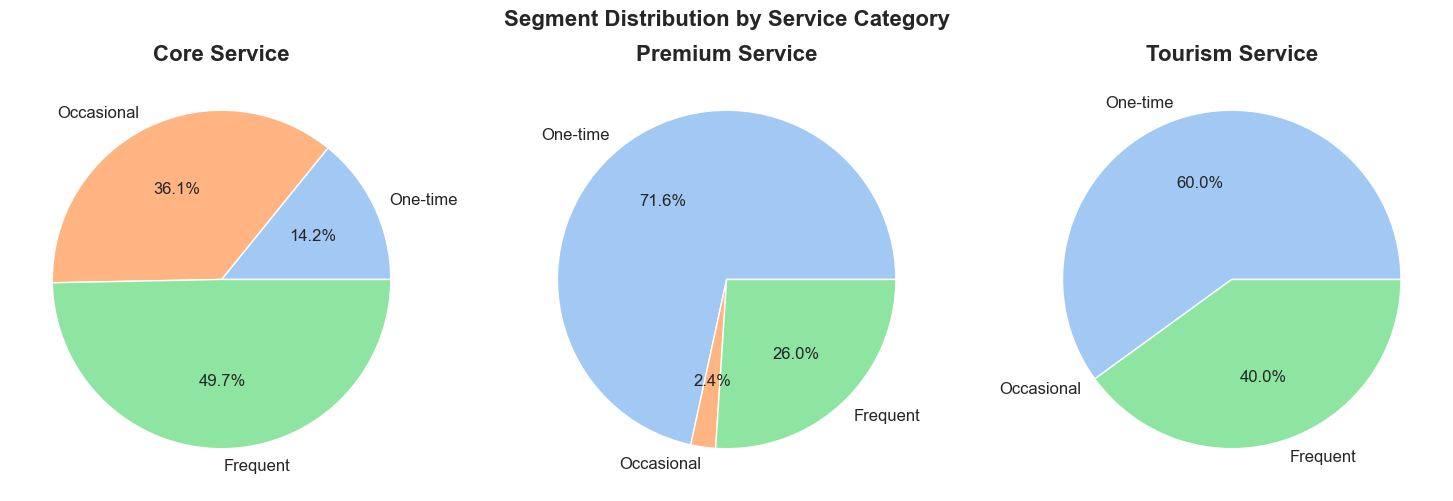

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

segment_order = ['One-time', 'Occasional', 'Frequent']

def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 0 else ''

for i, (service, d) in enumerate(user_freq.groupby('serviceCategory')):
    segment_pct = (
        d['segment']
        .value_counts(normalize=True)
        .mul(100)
        .reindex(segment_order, fill_value=0)
    )
    
    axes[i].pie(
        segment_pct.values,
        labels=segment_order,
        autopct=autopct_format
    )
    axes[i].set_title(service)

plt.suptitle('Segment Distribution by Service Category', size=16, y=1, fontweight='semibold')
plt.tight_layout()
plt.show()

For premium and tourist services, a high one-time rate is expected (71.6% and 60% respectively), and it reflects their role as services for single or infrequent use. For core services, however, the high proportion of frequent users (49.7%) indicates strong loyalty and daily dependence. But the occasional segment (36.1%) in core service still represents a valuable opportunity to push toward frequent status.

---

## **8. Key Insights & Recommendations**

Based on the analysis, the following strategic recommendations aim to optimize operations, improve user experience, and increase business performance.

### 8.1. Adjust Services for Working Age & Gender

- **Insight:** 
    - Working-age users dominate all Transjakarta service categories, indicating that the system primarily serves daily commuters.
    - Female users represent the majority (53%) across the overall user base, suggesting a slightly higher reliance on public transport among women.
- **Recommendation:**
    - Consider offering early morning and late evening services tailored for working professionals (e.g., from industrial zones or office parks).
    - Ensure that safety and comfort features (e.g., women-only areas on busy buses, well-lit stops, CCTV coverage) are prioritized, given the high proportion of female commuters.


### 8.2. Diversify Payment Methods & Leverage Bank DKI's Dominance

- **Insight:** Bank DKI dominates ~49% of transactions and over 70% in Tourism services.
- **Recommendation:**
    - **Short-term:** Strengthen the partnership with Bank DKI to offer exclusive cashback or discounts for frequent users, deepening loyalty within the dominant channel.
    - **Medium-term:** Actively promote alternative payment methods (eMoney, Brizzi, QRIS, or other bank cards) with sign-up bonuses or discounted first trips to encourage adoption.
    - **Long-term:** Integrate with national QRIS standard to allow any digital wallet or banking app to be used, increasing accessibility for occasional and one-time users.

### 8.3. Optimize Fleet & Schedule During Peak Hours

- **Insight:** Peak hours (7 AM and 6 PM) show very high demand, especially for Core Services. The evening peak (6 PM) is higher than the morning peak, suggesting heavier congestion and return travel.
- **Recommendation:**
    - Increase the frequency of Core Service vehicles during peak hours (06:00–10:00 and 17:00–20:00) to reduce passenger waiting times and overcrowding.
    - Deploy more reserve buses specifically for the evening peak (6 PM) to accommodate the higher volume of return trips.

### 8.4. Enhance Weekend Service

- **Insight:** Trip volume drops significantly on weekends, indicating that the service is heavily weekday-oriented.
- **Recommendation:**
    - While maintaining core weekday frequency, consider introducing **special weekend routes** targeting leisure destinations (malls, tourist sites, recreational areas) to boost weekend ridership.
    - Offer **family or group discounts** on weekends to attract non-commuter users.

### 8.5. Convert Occasional Users into Frequent Users in Core Services

- **Insight:** Occasional users make up 33.2% of total users (and 36.1% in Core Service), representing a large untapped opportunity for increasing loyalty.
- **Recommendation:**
    - Launch a **loyalty program** offering rewards after a certain number of trips per month (e.g., free trip after 10 trips, or discount vouchers).
    - Introduce **subscription or multi-trip passes** (e.g., 30-trip pass at a discounted rate) to encourage commitment.

### 8.6. Tailor Marketing Strategies in Premium and Tourism Services

- **Insight:** Premium and Tourism services have very high one-time user rates (71.6% and 60% respectively)
- **Recommendation:**
    - **For Premium Service:** Target **cross-regional commuters and office workers** traveling between Jakarta and surrounding areas (Jabodetabek) by offering bundled commuter passes and building partnerships with employers and transport hubs to increase repeat usage and shift one-time users into regular commuters.

    - **For Tourism Service:** Collaborate with **tourism boards, hotels, and travel agencies** to bundle Bus Wisata tickets with other tourist attractions. Create day-pass or hop-on-hop-off packages to encourage repeat usage within a single visit.
